In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# 1. Memuat data
# Pastikan file CSV berada di folder yang sama dengan script ini
# Jika menggunakan file Excel asli (.xlsx), ganti menjadi pd.read_excel('nama_file.xlsx')
file_path = 'CH Bulanan 7 Stasiun.csv'
df = pd.read_csv(file_path)

In [ ]:
# 2. Pra-pemrosesan Data
# FIX: Tambahkan format='%b-%y' agar '09' dibaca sebagai '2009', bukan tahun 9 Masehi.
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')

    # Set tanggal sebagai index
    df.set_index('Date', inplace=True)

In [ ]:
# 3. Menghitung Matriks Korelasi (Pearson Correlation)
# Metode 'pearson' adalah standar untuk mengukur hubungan linear
correlation_matrix = df.corr(method='pearson')

# Menampilkan nilai korelasi dalam bentuk tabel di console
print("Matriks Korelasi:")
print(correlation_matrix)

Matriks Korelasi:
                    Dendang  Pulau Tengah    Tamiai     Sipin  Siulak Deras  \
Dendang            1.000000      0.339435  0.281104  0.386767      0.272399   
Pulau Tengah       0.339435      1.000000  0.331852  0.222060      0.562308   
Tamiai             0.281104      0.331852  1.000000  0.326323      0.470768   
Sipin              0.386767      0.222060  0.326323  1.000000      0.251632   
Siulak Deras       0.272399      0.562308  0.470768  0.251632      1.000000   
Koto Limau Sering  0.163134      0.137573  0.170310  0.084982      0.091316   
Semurup            0.211389      0.351992  0.642560  0.404414      0.439646   

                   Koto Limau Sering   Semurup  
Dendang                     0.163134  0.211389  
Pulau Tengah                0.137573  0.351992  
Tamiai                      0.170310  0.642560  
Sipin                       0.084982  0.404414  
Siulak Deras                0.091316  0.439646  
Koto Limau Sering           1.000000  0.237987  
Semuru

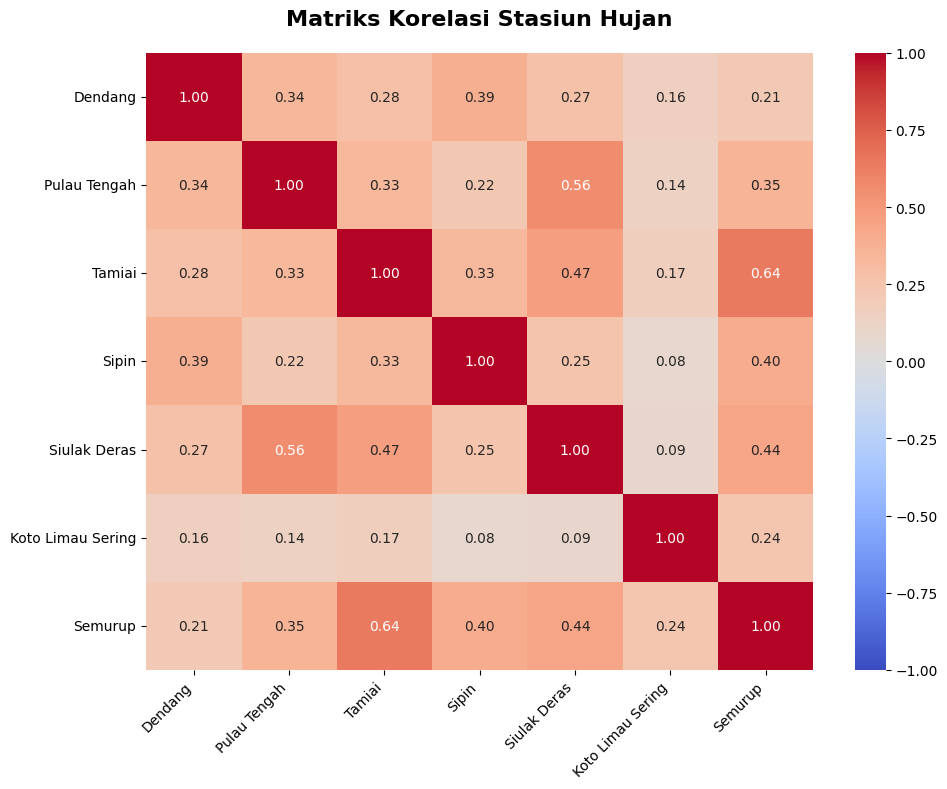

In [ ]:
# 4. Visualisasi dengan Heatmap
plt.figure(figsize=(10, 8)) # Mengatur ukuran gambar

# Membuat heatmap
# annot=True: menampilkan angka korelasi di dalam kotak
# cmap='coolwarm': skema warna (merah=tinggi, biru=rendah)
# vmin=-1, vmax=1: batas skala korelasi
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

# Menambahkan judul dan label
plt.title('Matriks Korelasi Stasiun Hujan', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # Memutar label sumbu X agar mudah dibaca
plt.yticks(rotation=0)

# Menyimpan gambar hasil plot (opsional)
plt.tight_layout()
plt.savefig('korelasi_hujan.png', dpi=300)

# Menampilkan plot
plt.show()